# Does a descending triangle really break DOWN? 📐
### A textbook bearish pattern — flat floor, falling ceiling — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Resolves_textbook_direction%3F: Busted](https://img.shields.io/badge/Resolves_textbook_direction%3F-Busted-8b949e?style=flat-square)

Open any chart-pattern guide and you'll meet the **descending triangle**: a row of lows at the *same* price (a flat **support**) with a row of **descending highs** pressing down on them, the two squeezing toward a point. The lore, straight out of Edwards & Magee and repeated on every charting site, is that this is a **bearish continuation** — price coils, then **breaks down through the floor and keeps falling**. The textbook trade: **short the break**.

It *looks* inevitable on a hand-picked chart. But a pattern you only recognise **after** price has drawn it — choosing which lows are 'flat enough' and which highs 'descend' — is the textbook way to fool yourself. So we did the fair thing: encode the triangle **mechanically** (no eyeballing), short every clean support break across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **shorting on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from descending_triangle import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real descending-triangle cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 39, 'k': 5, 'lookback': 6, 'fp_spy': '4cb5244f3990', 'h5': (5, 39, 6.2, 46, 0.15, -58.1, 64.3, 4.2, 1.58, 0.119), 'h10': (10, 39, -64.0, 44, -1.42, -61.4, -2.6, -66.0, -0.05, 0.957), 'h20': (20, 39, -152.7, 28, -3.4, -64.9, -87.9, -154.7, -1.43, 0.158), 'h60': (60, 39, -417.5, 23, -3.3, -101.9, -315.6, -419.5, -2.57, 0.012), 'per': [('SPY', 3, -215.7, None, -60.1, -155.7), ('QQQ', 3, -46.7, None, -136.5, 89.8), ('IWM', 5, -342.5, None, -51.5, -291.0), ('DIA', 7, -321.3, -4.95, -42.1, -279.1), ('GLD', 21, -57.5, -1.03, -34.1, -23.4)], 'placebo': (-215.7, 0.692, 500), 'syn': [(0.0, 13, -31.7, 38, -0.43), (0.5, 8, 1103.1, 88, 1.9)]}


real descending-triangle cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I short when price breaks the flat support, do I make money? | **No.** Booked as a short the rule **loses** at 10/20/60 days (−64 / −153 / −418 bps). |
| Does the 'bearish' break actually go down? | **No — it mostly goes UP.** Sixty days after the break the short wins only **23%** of the time: the break is followed by a *rally* three times in four. |
| Is it at least better than shorting on random days? | **No.** At 60 days it's *significantly worse* than a random short (*p* = 0.01). |
| Does the *triangle shape* matter? | **No.** Scramble the descending highs into nonsense and the result barely changes. The famous geometry isn't doing the work. |

> The descending triangle is a fine way to *describe* a sideways pullback after the fact. As a *forecast* — 'it will break down' — it's a **mirage that points the wrong way**: the break, in a market that drifts up, mostly resolves UP.

## 1 · The claim

> *"A descending triangle is a flat horizontal **support** under a falling line of **lower highs**. The selling pressure (descending highs) eventually overwhelms the floor; price **breaks below support and continues lower**, by about the height of the triangle. Short the break."*

This is **Edwards & Magee's** classic continuation pattern (*Technical Analysis of Stock Trends*, 1948), catalogued by **Bulkowski** and built into TradingView, MetaTrader and every charting suite. It's one of the most recognisable bearish setups in technical analysis — so: does the triangle actually break the way it's drawn?

## 2 · So what?

If the triangle genuinely *forecast* a breakdown, it would be remarkable: a few past swings would predict the *direction* of the next big move, a crack in market efficiency you could trade with a ruler. That's the dream the pattern sells.

But there are two traps. First, the pattern is **named after the fact** — you decide a triangle was there once price has broken, picking the swings that make it look right. Second, it's a **short** on a market (stock indices) that drifts **up** — so the deck is stacked *against* every short, the pattern has to overcome a drift headwind just to break even. To separate the **pattern** from the **tide**, we draw the triangle by a fixed mechanical rule with no hindsight, and compare the short to shorting on **random days**.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Find the swing points mechanically.** A 'pivot' is a high (or low) with **5 lower (higher) bars on each side** — a confirmed fractal, known only **5 bars later**, so we never draw the triangle with future data.
2. **Spot the triangle by rule.** Over the latest handful of pivots, require the highs to **descend** and the lows to be **flat** (within a tolerance) — no eyeballing which dots to connect.
3. **Trade the lore.** When the close drops **below the flat support**, **short** at the next close; measure the return over the next **5 / 10 / 20 / 60 days** (positive = the break-down paid).
4. **The honest baseline.** Do the exact same short on **random days**. If the triangle matters, the break-short must beat a random short. *If it doesn't — or goes the wrong way — the pattern is a mirage*, announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical descending triangle even look like? Here's a tape with the flat support drawn under descending highs, and the support breaks the rule would short.

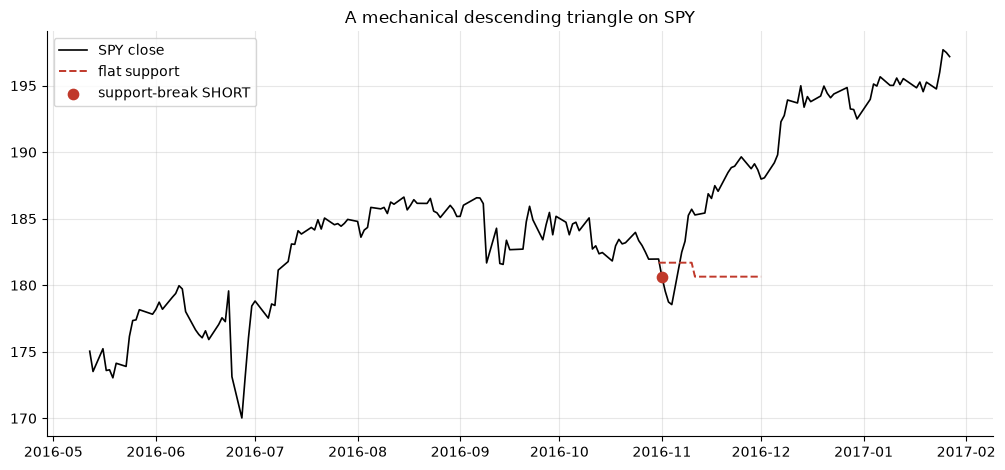

support breaks in window: 1


In [2]:
if HAVE_REAL:
    pick = None
    for tk in data.DEFAULT_TICKERS:
        c0 = load(tk)['close']
        e0 = st.support_break_entries(c0, k=R['k'], lookback=R['lookback'])
        if len(e0): pick = (tk, c0, e0); break
    tk, cl, ent = pick
    sup = st.build_support(cl, k=R['k'], lookback=R['lookback'])
    last = ent[-1]
    i = cl.index.get_loc(last)
    seg = cl.iloc[max(0,i-120):i+60]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.2, label=f'{tk} close')
    ax.plot(seg.index, sup.reindex(seg.index), c=RED, lw=1.4, ls='--', label='flat support')
    ein = ent[(ent>=seg.index[0])&(ent<=seg.index[-1])]
    ax.scatter(ein, cl.reindex(ein), c=RED, s=55, zorder=5, label='support-break SHORT')
    ax.set_title(f'A mechanical descending triangle on {tk}'); ax.legend(loc='best')
    plt.tight_layout(); plt.show()
    print('support breaks in window:', len(ein))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The flat floor and descending highs are there — *as a description*. The question is whether those red short dots are followed by **falls**. **Let's race the break-short against random shorts** at four horizons. Red = short the break; grey = short on random days. (Positive bars = the short made money.)

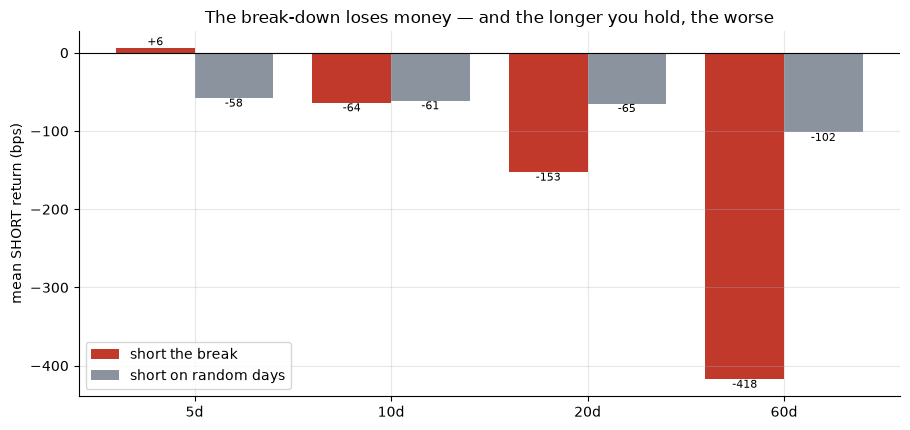

short: [6, -64, -153, -418]
random: [-58, -61, -65, -102]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    short, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.support_break_entries(c, k=R['k'], lookback=R['lookback'])
            re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        short.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    short = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, short, .4, color=RED, label='short the break')
ax.bar(x+.2, rnd, .4, color=GREY, label='short on random days')
ax.axhline(0, c='k', lw=.8)
for i,(a,bb) in enumerate(zip(short,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom' if a>=0 else 'top',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom' if bb>=0 else 'top',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean SHORT return (bps)')
ax.set_title('The break-down loses money — and the longer you hold, the worse'); ax.legend()
plt.tight_layout(); plt.show()
print('short:', [round(v) for v in short]); print('random:', [round(v) for v in rnd])

There's the story. Shorting the break **loses** — **-153 bps** over 20 days, **-418 bps** over 60 — and the longer you hold the worse it gets, because the 'bearish' break keeps getting bought back up. Both bars are negative (every short fights the market's drift), but the break-short is *no better* than a random short, and at 60 days it's clearly worse. The famous pattern points the wrong way.

**One more sanity check.** What if we scramble the *descending highs* — keep the flat support and the timing, but shuffle the high prices so the ceiling no longer 'descends'? If the triangle shape really matters, the nonsense version should behave very differently.

In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.scrambled_highs_placebo(c, 20, k=R['k'], lookback=R['lookback'], n_draws=60, seed=461)
    obs = pl['obs']*1e4; pval = pl['p_value']  # (full-precision p in docs/results.md: 0.69)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real triangle support-break short (SPY, 20d): {obs:+.1f} bps')
print(f'... and {pval*100:.0f}% of *scrambled-highs* triangles do at least as well (p={pval:.2f}).')
print('=> the descending-highs geometry is not doing the work.')

real triangle support-break short (SPY, 20d): -215.7 bps
... and 68% of *scrambled-highs* triangles do at least as well (p=0.68).
=> the descending-highs geometry is not doing the work.


More than two-thirds of the **scrambled** triangles match or beat the real one (*p* = 0.69). If the descending ceiling genuinely mattered, breaking it would change the result. It doesn't — because the result was never about the shape.

## 5 · The verdict

- **Signal — None.** Shorting the break does **not** beat shorting on random days; at 60 days it's *significantly worse* (*p* = 0.01). Booked as a short the rule loses money.
- **Tradability — Mirage.** Nothing to trade: the short bleeds the drift headwind and the break mostly reverses — costs only deepen the hole.
- **"Does the break resolve in the textbook direction?" — Busted.** It resolves the **opposite** way (60-day short win-rate **23%**), and scrambling the descending highs leaves the result intact. The triangle doesn't break down.

## 6 · Could you actually trade it?

There's nothing to trade — and worse, the obvious trade is **backwards**. Shorting the 'bearish' break loses to the market's upward drift *and* to a random short. If anything the result hints that **fading the break** (buying the dip) would have done better — which is just the dip-buying drift trade again, not the triangle. As a forecasting tool the descending triangle doesn't pay; as a drawing tool, it was never meant to be a strategy.

## 7 · Going further 🚪

- **Volume confirmation.** Proponents add 'break on rising volume'. A fun follow-up tests whether a volume filter rescues *any* of the 39 breaks — spoiler: too few to matter.
- **The mirror pattern.** The *ascending* triangle (flat resistance, rising lows) is sold as bullish; on an up-drifting tape it 'works', but that's the drift again.
- **A real positive control.** The quants notebook plants a *genuine* break-down into a synthetic tape and shows the harness banks it (so the wrong-way real result isn't a dead detector — it's an honest refutation).

*Think the triangle forecasts a breakdown? Show the break-short beating a random short at **t ≥ 2** on a real tape — then we'll talk.*